# Módulo 3 - Desafio 4
## Tabaquismo y gestación

En este documento validaremos nuestros conocimientos sobre variables aleatorias. Para ello exploraremos un dataset que contiene información básica sobre el bebe y la madre.

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

df_baby = pd.read_csv('baby.csv')
df_baby.head()

,Unnamed: 0,Birth.Weight,Gestational.Days,Maternal.Age,Maternal.Height,Maternal.Pregnancy.Weight,Maternal.Smoker
0,1,120,284,27,62,100,False
1,2,113,282,33,64,135,False
2,3,128,279,28,64,115,True
3,4,108,282,23,67,125,True
4,5,136,286,25,62,93,False


In [14]:
# Tenemos una columna adicional que corresponde al índice de los datos. La eliminaremos.
df_baby.drop(columns=['Unnamed: 0'], inplace=True)

### Pregunta 1
Realiza una exploración de los datos, considerando sus tipos y los descriptivos correspondientes.

In [15]:
df_baby.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1174 entries, 0 to 1173
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Birth.Weight               1174 non-null   int64
 1   Gestational.Days           1174 non-null   int64
 2   Maternal.Age               1174 non-null   int64
 3   Maternal.Height            1174 non-null   int64
 4   Maternal.Pregnancy.Weight  1174 non-null   int64
 5   Maternal.Smoker            1174 non-null   bool 
dtypes: bool(1), int64(5)
memory usage: 47.1 KB


Vemos que todos los datos son numéricos, excepto Maternal.Smoker que corresponde a un boolean. Puede interpretarse como una variable categórica (es o no fumadora).

In [16]:
df_baby.isna().sum()

Birth.Weight                 0
Gestational.Days             0
Maternal.Age                 0
Maternal.Height              0
Maternal.Pregnancy.Weight    0
Maternal.Smoker              0
dtype: int64

Datos limpios sin nulos.

In [17]:
df_baby.describe().T

,count,mean,std,min,25%,50%,75%,max
Birth.Weight,1174.0,119.462521,18.328671,55.0,108.00,120.0,131.0,176.0
Gestational.Days,1174.0,279.101363,16.010305,148.0,272.00,280.0,288.0,353.0
Maternal.Age,1174.0,27.228279,5.817839,15.0,23.00,26.0,31.0,45.0
Maternal.Height,1174.0,64.049404,2.526102,53.0,62.00,64.0,66.0,72.0
Maternal.Pregnancy.Weight,1174.0,128.478705,20.734282,87.0,114.25,125.0,139.0,250.0


In [18]:
df_baby['Birth.Weight'].skew(), df_baby['Birth.Weight'].kurtosis()

(np.float64(-0.1333808459748732), np.float64(0.44134313942893666))

### Pregunta 2
Considera los pesos de los bebés. ¿Se puede decir que siguen una distribución normal? Justifica tu respuesta creando los gráficos y modelos necesarios.

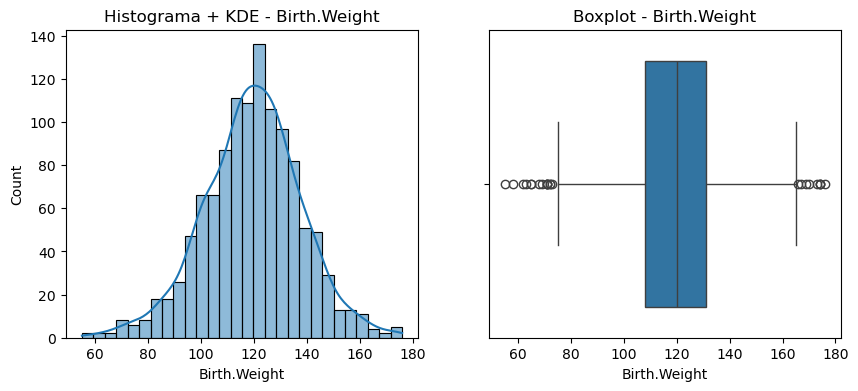

In [19]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df_baby['Birth.Weight'], kde=True)
plt.title('Histograma + KDE - Birth.Weight')

plt.subplot(1,2,2)
sns.boxplot(x=df_baby['Birth.Weight'])
plt.title('Boxplot - Birth.Weight')
plt.show()